# **Merge results**

In this notebook the results of all notebooks/datasets will be merged into one table for each evaluation method. Additionally, the average over all datasets will be added.

In [28]:
# Loads the required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## **Resemblance**

**Difference in pairwise correlation:**

In [29]:
# Load the PCD results
corr_diff = pd.read_csv('../data/results/tables/corr_diff.csv')

# Pivot the data to wide format
corr_diff_wide = corr_diff.pivot(index='Dataset', columns='Model', values='Pairwise Corr Diff')

# Calculate the mean correlation difference and standard deviation for each model
pcd_avg = corr_diff_wide.mean(axis=0)
pcd_std = corr_diff_wide.std(axis=0)

# Combine into formatted strings: "mean ± std"
avg_std = pcd_avg.round(3).astype(str) + " ± " + pcd_std.round(3).astype(str)

# Append the new row to the dataframe
corr_diff_wide.loc['Avg ± SD'] = avg_std

# # Round the values to 3 decimal places
corr_diff_wide = corr_diff_wide.round(3)

# Save the wide format table to a CSV file
corr_diff_wide.to_csv('../final_results/combined_tables/corr_diff.csv')

# # Print as latex table
print(corr_diff_wide.to_latex(
    index=True,                 # Print row names
    float_format="%.3f",        # Set precision
    escape=True,                # Escape special characters      
    column_format="lcccccc",    # Align columns
    header=True,                # Print column names
    label="tab:corr_diff",        # Set label
    caption="Difference in Pairwise Correlation", # Set caption       
))
corr_diff_wide


\begin{table}
\caption{Difference in Pairwise Correlation}
\label{tab:corr_diff}
\begin{tabular}{lcccccc}
\toprule
Model & copula\_gan & ctgan & ds & gaussian\_copula & synthpop & tvae \\
Dataset &  &  &  &  &  &  \\
\midrule
1 & 0.157 & 0.163 & 0.155 & 0.117 & 0.058 & 0.150 \\
2 & 0.198 & 0.194 & 0.177 & 0.069 & 0.025 & 0.166 \\
3 & 0.283 & 0.276 & 0.281 & 0.233 & 0.158 & 0.192 \\
4 & 0.030 & 0.029 & 0.035 & 0.035 & 0.006 & 0.025 \\
5 & 0.099 & 0.099 & 0.136 & 0.088 & 0.069 & 0.112 \\
Avg ± SD & 0.153 ± 0.096 & 0.152 ± 0.094 & 0.157 ± 0.088 & 0.109 ± 0.076 & 0.063 ± 0.059 & 0.129 ± 0.065 \\
\bottomrule
\end{tabular}
\end{table}



Model,copula_gan,ctgan,ds,gaussian_copula,synthpop,tvae
Dataset,,,,,,
1,0.156744,0.162528,0.154599,0.116951,0.058116,0.149854
2,0.197659,0.193518,0.177231,0.069194,0.024836,0.166282
3,0.282757,0.276339,0.280987,0.233152,0.158428,0.19177
4,0.030462,0.029021,0.035256,0.035348,0.005884,0.025112
5,0.098838,0.099111,0.135631,0.088445,0.068662,0.112384
Avg ± SD,0.153 ± 0.096,0.152 ± 0.094,0.157 ± 0.088,0.109 ± 0.076,0.063 ± 0.059,0.129 ± 0.065


**Jensen-Shannon Divergence**

In [30]:
# Load JSD results
jsd = pd.read_csv('../data/results/tables/jsd.csv')

# Pivot the data to create a wide format table
jsd_wide = jsd.pivot(index='Dataset', columns='Model', values='JSD Diff')

# Calculate the mean and standard deviation for each model
jsd_avg = jsd_wide.mean(axis=0)
jsd_std = jsd_wide.std(axis=0)

# Combine the mean and standard deviation into formatted strings: "mean ± std"
jsd_avg_std = jsd_avg.round(3).astype(str) + " ± " + jsd_std.round(3).astype(str)

# Append the new row to the dataframe
jsd_wide.loc['Avg ± SD'] = jsd_avg_std

# Round the values to 3 decimal places
jsd_wide = jsd_wide.round(3)

# Save the wide format table to a CSV file
jsd_wide.to_csv('../final_results/combined_tables/jsd.csv')

# Print as latex table
print(jsd_wide.to_latex(
    index=True,                 # Print row names
    float_format="%.3f",        # Set precision
    escape=True,                # Escape special characters
    column_format="lcccccc",    # Align columns
    header=True,                # Print column names
    label="tab:jsd",        # Set label
    caption="Jensen-Shannon Divergence", # Set caption       
))

jsd_wide

\begin{table}
\caption{Jensen-Shannon Divergence}
\label{tab:jsd}
\begin{tabular}{lcccccc}
\toprule
Model & copula\_gan & ctgan & ds & gaussian\_copula & synthpop & tvae \\
Dataset &  &  &  &  &  &  \\
\midrule
1 & 0.045 & 0.064 & 0.089 & 0.051 & 0.030 & 0.152 \\
2 & 0.039 & 0.050 & 0.060 & 0.011 & 0.006 & 0.076 \\
3 & 0.182 & 0.168 & 0.201 & 0.185 & 0.040 & 0.196 \\
4 & 0.074 & 0.066 & 0.113 & 0.107 & 0.013 & 0.075 \\
5 & 0.025 & 0.026 & 0.094 & 0.010 & 0.003 & 0.173 \\
Avg ± SD & 0.073 ± 0.064 & 0.075 ± 0.055 & 0.111 ± 0.053 & 0.073 ± 0.074 & 0.018 ± 0.016 & 0.135 ± 0.056 \\
\bottomrule
\end{tabular}
\end{table}



Model,copula_gan,ctgan,ds,gaussian_copula,synthpop,tvae
Dataset,,,,,,
1,0.045132,0.064247,0.089329,0.0507,0.029851,0.152463
2,0.039251,0.049533,0.059914,0.010896,0.006083,0.076419
3,0.182385,0.16817,0.200728,0.184877,0.040269,0.196065
4,0.074107,0.065716,0.112649,0.106737,0.012889,0.075311
5,0.024876,0.026296,0.094244,0.009733,0.002518,0.173274
Avg ± SD,0.073 ± 0.064,0.075 ± 0.055,0.111 ± 0.053,0.073 ± 0.074,0.018 ± 0.016,0.135 ± 0.056


**Wasserstein distance**

In [31]:
# Load WD results
wd = pd.read_csv('../data/results/tables/wd.csv')

# Pivot the data to create a wide format table
wd_wide = wd.pivot(index='Dataset', columns='Model', values='WD Diff')

# Calculate the average and standard deviation for each model
wd_avg = wd_wide.mean(axis=0)
wd_std = wd_wide.std(axis=0)

# Combine the average and standard deviation into formatted strings: "mean ± std"
wd_avg_std = wd_avg.round(3).astype(str) + " ± " + wd_std.round(3).astype(str)

# Append the new row to the dataframe
wd_wide.loc['Avg ± SD'] = wd_avg_std

# Round the values to 3 decimal places
wd_wide = wd_wide.round(3)

# Save the wide format table to a CSV file
wd_wide.to_csv('../final_results/combined_tables/wd.csv')

# Print as latex table
print(wd_wide.to_latex(
    index=True,                 # Print row names
    float_format="%.3f",        # Set precision
    escape=True,                # Escape special characters
    column_format="lcccccc",    # Align columns
    header=True,                # Print column names
    label="tab:wd",        # Set label
    caption="Wasserstein Distance", # Set caption       
))

wd_wide

\begin{table}
\caption{Wasserstein Distance}
\label{tab:wd}
\begin{tabular}{lcccccc}
\toprule
Model & copula\_gan & ctgan & ds & gaussian\_copula & synthpop & tvae \\
Dataset &  &  &  &  &  &  \\
\midrule
1 & 0.027 & 0.014 & 0.055 & 0.015 & 0.021 & 0.120 \\
2 & 0.031 & 0.019 & 0.047 & 0.009 & 0.007 & 0.092 \\
3 & 0.036 & 0.037 & 0.080 & 0.035 & 0.022 & 0.135 \\
4 & 0.023 & 0.019 & 0.016 & 0.005 & 0.002 & 0.026 \\
5 & 0.040 & 0.036 & 0.124 & 0.016 & 0.021 & 0.274 \\
Avg ± SD & 0.031 ± 0.007 & 0.025 ± 0.011 & 0.064 ± 0.04 & 0.016 ± 0.012 & 0.014 ± 0.009 & 0.13 ± 0.091 \\
\bottomrule
\end{tabular}
\end{table}



Model,copula_gan,ctgan,ds,gaussian_copula,synthpop,tvae
Dataset,,,,,,
1,0.027005,0.013659,0.054549,0.015245,0.020604,0.119978
2,0.030629,0.0189,0.047,0.008848,0.006857,0.091917
3,0.036021,0.036824,0.079663,0.035398,0.021643,0.135307
4,0.02306,0.018926,0.016251,0.004953,0.001847,0.026468
5,0.04043,0.035582,0.124192,0.015656,0.021479,0.274399
Avg ± SD,0.031 ± 0.007,0.025 ± 0.011,0.064 ± 0.04,0.016 ± 0.012,0.014 ± 0.009,0.13 ± 0.091


## **Privacy**

**Distance to Closest Record**

In [32]:
# Load DCR results
dcr_test = pd.read_csv('../data/results/tables/dcr.csv')

# Calculate average values for each model
average_values = dcr_test.groupby('Model')[['DCR 5th Percentile', 'DCR 5th Percentile (within Real)', 'DCR 5th Percentile (within Synthetic)']].mean().reset_index()

final_data = []

for model in dcr_test['Model'].unique():
    
    model_data = dcr_test[dcr_test['Model'] == model]
    
    for idx, row in model_data.iterrows():
        if idx == model_data.index[2]:  # Only add model name once
            final_data.append([row['Model'], row['Dataset'], row['DCR 5th Percentile'], row['DCR 5th Percentile (within Real)'], row['DCR 5th Percentile (within Synthetic)']])
        else:
            final_data.append(['', row['Dataset'], row['DCR 5th Percentile'], row['DCR 5th Percentile (within Real)'], row['DCR 5th Percentile (within Synthetic)']])
    
    # Add average values
    avg_row = average_values[average_values['Model'] == model].iloc[0]
    final_data.append(['', 'Average', avg_row['DCR 5th Percentile'], avg_row['DCR 5th Percentile (within Real)'], avg_row['DCR 5th Percentile (within Synthetic)']])

# Create final dataframe
dcr_df = pd.DataFrame(final_data, columns=['Model', 'Dataset', 'Between Synth/Real', 'Within Real', 'Within Synth']).round(3)
dcr_df.to_csv('../final_results/combined_tables/dcr.csv', index=False)

# Print as latex table
print(dcr_df.to_latex(
    index=False,                 # Print row names
    float_format="%.2f",        # Set precision
    escape=True,                # Escape special characters
    bold_rows=True,             # Bold row names
    column_format="ccccc",    # Align columns
    header=True,                # Print column names
    label="tab:dcr",        # Set label
    caption="Distance to Closest Record", # Set caption       
))

\begin{table}
\caption{Distance to Closest Record}
\label{tab:dcr}
\begin{tabular}{ccccc}
\toprule
Model & Dataset & Between Synth/Real & Within Real & Within Synth \\
\midrule
 & 1 & 6.22 & 5.57 & 6.48 \\
 & 2 & 1.41 & 1.73 & 1.41 \\
synthpop & 3 & 6.02 & 6.01 & 5.85 \\
 & 4 & 2.45 & 2.24 & 2.45 \\
 & 5 & 3.71 & 3.71 & 3.74 \\
 & Average & 3.96 & 3.85 & 3.99 \\
 & 1 & 12.15 & 5.57 & 11.31 \\
 & 2 & 3.87 & 1.73 & 2.45 \\
ds & 3 & 47.45 & 6.01 & 28.48 \\
 & 4 & 10.54 & 2.24 & 9.80 \\
 & 5 & 6.67 & 3.71 & 4.97 \\
 & Average & 16.14 & 3.85 & 11.40 \\
 & 1 & 7.51 & 5.57 & 5.38 \\
 & 2 & 2.00 & 1.73 & 1.41 \\
tvae & 3 & 7.25 & 6.01 & 6.16 \\
 & 4 & 5.83 & 2.24 & 5.00 \\
 & 5 & 4.24 & 3.71 & 2.00 \\
 & Average & 5.37 & 3.85 & 3.99 \\
 & 1 & 8.45 & 5.57 & 7.94 \\
 & 2 & 1.73 & 1.73 & 1.73 \\
gaussian\_copula & 3 & 10.52 & 6.01 & 11.07 \\
 & 4 & 13.04 & 2.24 & 12.17 \\
 & 5 & 4.24 & 3.71 & 4.24 \\
 & Average & 7.59 & 3.85 & 7.43 \\
 & 1 & 12.02 & 5.57 & 11.56 \\
 & 2 & 3.46 & 1.73 & 2.83 \\
co

**Nearest Neighbour Distance Ratio**

In [33]:
# Load NNDR results
nndr_test = pd.read_csv('../data/results/tables/nndr.csv')

# Calculate average values for each model
average_values = nndr_test.groupby('Model')[['NNDR 5th percentile', 'NNDR 5th percentile (within Real)', 'NNDR 5th percentile (within Synthetic)']].mean().reset_index()

final_data = []

for model in nndr_test['Model'].unique():
    
    model_data = nndr_test[nndr_test['Model'] == model]
    
    for idx, row in model_data.iterrows():
        if idx == model_data.index[2]:  # Only add model name once
            final_data.append([row['Model'], row['Dataset'], row['NNDR 5th percentile'], row['NNDR 5th percentile (within Real)'], row['NNDR 5th percentile (within Synthetic)']])
        else:
            final_data.append(['', row['Dataset'], row['NNDR 5th percentile'], row['NNDR 5th percentile (within Real)'], row['NNDR 5th percentile (within Synthetic)']])
    
    # Add average values
    avg_row = average_values[average_values['Model'] == model].iloc[0]
    final_data.append(['', 'Average', avg_row['NNDR 5th percentile'], avg_row['NNDR 5th percentile (within Real)'], avg_row['NNDR 5th percentile (within Synthetic)']])

# Create final dataframe
nndr_df = pd.DataFrame(final_data, columns=['Model', 'Dataset', 'Between Synth/Real', 'Within Real', 'Within Synth']).round(3)
nndr_df.to_csv('../final_results/combined_tables/nndr.csv', index=False)

# Print as latex table
print(nndr_df.to_latex(
    index=False,                 # Print row names
    float_format="%.3f",        # Set precision
    escape=True,                # Escape special characters
    bold_rows=True,             # Bold row names
    column_format="ccccc",    # Align columns
    header=True,                # Print column names
    label="tab:nndr",        # Set label
    caption="Nearest Neighbour Distance Ratio", # Set caption       
))

\begin{table}
\caption{Nearest Neighbour Distance Ratio}
\label{tab:nndr}
\begin{tabular}{ccccc}
\toprule
Model & Dataset & Between Synth/Real & Within Real & Within Synth \\
\midrule
 & 1 & 0.439 & 0.493 & 0.449 \\
 & 2 & 0.408 & 0.555 & 0.425 \\
synthpop & 3 & 0.426 & 0.583 & 0.449 \\
 & 4 & 0.046 & 0.073 & 0.072 \\
 & 5 & 0.750 & 0.771 & 0.791 \\
 & Average & 0.414 & 0.495 & 0.437 \\
 & 1 & 0.560 & 0.493 & 0.569 \\
 & 2 & 0.756 & 0.555 & 0.371 \\
ds & 3 & 0.497 & 0.583 & 0.517 \\
 & 4 & 0.223 & 0.073 & 0.216 \\
 & 5 & 0.403 & 0.771 & 0.663 \\
 & Average & 0.488 & 0.495 & 0.467 \\
 & 1 & 0.564 & 0.493 & 0.522 \\
 & 2 & 0.577 & 0.555 & 0.458 \\
tvae & 3 & 0.557 & 0.583 & 0.479 \\
 & 4 & 0.188 & 0.073 & 0.180 \\
 & 5 & 0.858 & 0.771 & 0.000 \\
 & Average & 0.549 & 0.495 & 0.328 \\
 & 1 & 0.557 & 0.493 & 0.499 \\
 & 2 & 0.555 & 0.555 & 0.577 \\
gaussian\_copula & 3 & 0.568 & 0.583 & 0.637 \\
 & 4 & 0.130 & 0.073 & 0.207 \\
 & 5 & 0.799 & 0.771 & 0.794 \\
 & Average & 0.522 & 0.495 & 0.5

**Membership inference attack**

In [34]:
# Load MIA results
df_mia_large = pd.read_csv('../data/results/tables/mia.csv')

# Calculate average value of all proportions for each threshold
large_test = df_mia_large.groupby(['Dataset', 'Model', 'Metric', 'Threshold'])[ 'Value'].median().round(3).reset_index()

# Calculate average for each model over all datasets
avg = large_test.groupby(['Model', 'Metric', 'Threshold'])['Value'].mean().reset_index().assign(Dataset='Average')
large_test = pd.concat([large_test, avg])

# Pivot table
wide_test = large_test.pivot(index=['Model', 'Dataset'], columns=['Threshold', 'Metric'], values='Value').round(3)
wide_test = wide_test.sort_index(axis=1, level=0)
wide_test.to_csv('../final_results/combined_tables/mia.csv')

# Print as latex table
print(wide_test.to_latex(
    index=True,                 # Print row names
    float_format="%.2f",        # Set precision
    escape=True,                # Escape special characters            # Bold row names
    column_format="cccccccccc",     # Align columns
    header=True,                # Print column names
    multicolumn=True,
    multirow=True,
    label="tab:mia",        # Set label
    caption="Membership Inference Attack", # Set caption       
))

wide_test


\begin{table}
\caption{Membership Inference Attack}
\label{tab:mia}
\begin{tabular}{cccccccccc}
\toprule
 & Threshold & \multicolumn{2}{r}{0.100000} & \multicolumn{2}{r}{0.200000} & \multicolumn{2}{r}{0.300000} & \multicolumn{2}{r}{0.400000} \\
 & Metric & accuracy & precision & accuracy & precision & accuracy & precision & accuracy & precision \\
Model & Dataset &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{6}{*}{copula\_gan} & 1 & 0.40 & 0.00 & 0.40 & 0.00 & 0.41 & 0.57 & 0.43 & 0.56 \\
 & 2 & 0.28 & 0.00 & 0.28 & 0.00 & 0.40 & 0.82 & 0.72 & 0.72 \\
 & 3 & 0.27 & 0.00 & 0.27 & 0.00 & 0.27 & 0.00 & 0.27 & 0.00 \\
 & 4 & 0.33 & 0.69 & 0.56 & 0.72 & 0.68 & 0.70 & 0.70 & 0.70 \\
 & 5 & 0.30 & 0.00 & 0.30 & 0.00 & 0.35 & 0.94 & 0.72 & 0.76 \\
 & Average & 0.32 & 0.14 & 0.36 & 0.14 & 0.42 & 0.61 & 0.57 & 0.55 \\
\cline{1-10}
\multirow[t]{6}{*}{ctgan} & 1 & 0.40 & 0.00 & 0.40 & 0.00 & 0.40 & 0.36 & 0.46 & 0.64 \\
 & 2 & 0.28 & 0.00 & 0.28 & 0.50 & 0.37 & 0.73 & 0.70 & 0.71 \\
 & 3 & 0.27

Threshold                    0.1                0.2                0.3  \
Metric                  accuracy precision accuracy precision accuracy   
Model           Dataset                                                  
copula_gan      1          0.400     0.000    0.400     0.000    0.410   
                2          0.280     0.000    0.280     0.000    0.400   
                3          0.270     0.000    0.270     0.000    0.270   
                4          0.330     0.690    0.560     0.720    0.680   
                5          0.300     0.000    0.300     0.000    0.350   
                Average    0.316     0.138    0.362     0.144    0.422   
ctgan           1          0.400     0.000    0.400     0.000    0.400   
                2          0.280     0.000    0.280     0.500    0.370   
                3          0.270     0.000    0.270     0.000    0.270   
                4          0.320     0.600    0.520     0.670    0.680   
                5          0.300     0.000    0.300     0.000    0.320   
                Average    0.314     0.120    0.354     0.234    0.408   
ds              1          0.400     0.000    0.400     0.000    0.400   
                2          0.280     0.000    0.290     1.000    0.320   
                3          0.270     0.000    0.270     0.000    0.270   
                4          0.300     0.800    0.390     0.690    0.660   
                5          0.300     0.000    0.300     0.000    0.300   
                Average    0.310     0.160    0.330     0.338    0.390   
gaussian_copula 1          0.400     0.000    0.400     0.000    0.440   
                2          0.280     0.000    0.280     0.420    0.420   
                3          0.270     0.000    0.270     0.000    0.270   
                4          0.300     0.780    0.370     0.660    0.650   
                5          0.300     0.000    0.300     0.000    0.340   
                Average    0.310     0.156    0.324     0.216    0.424   
synthpop        1          0.400     0.000    0.400     0.000    0.440   
                2          0.290     0.600    0.320     0.770    0.520   
                3          0.270     0.000    0.290     1.000    0.290   
                4          0.360     0.670    0.600     0.690    0.690   
                5          0.300     0.000    0.310     1.000    0.410   
                Average    0.324     0.254    0.384     0.692    0.470   
tvae            1          0.400     0.000    0.400     0.000    0.400   
                2          0.280     0.000    0.290     0.800    0.370   
                3          0.270     0.000    0.270     0.000    0.270   
                4          0.350     0.770    0.590     0.740    0.690   
                5          0.300     0.000    0.300     0.000    0.300   
                Average    0.320     0.154    0.370     0.308    0.406   

Threshold                              0.4            
Metric                  precision accuracy precision  
Model           Dataset                               
copula_gan      1           0.570    0.430     0.560  
                2           0.820    0.720     0.720  
                3           0.000    0.270     0.000  
                4           0.700    0.700     0.700  
                5           0.940    0.720     0.760  
                Average     0.606    0.568     0.548  
ctgan           1           0.360    0.460     0.640  
                2           0.730    0.700     0.710  
                3           0.000    0.270     0.000  
                4           0.700    0.700     0.700  
                5           0.800    0.720     0.770  
                Average     0.518    0.570     0.564  
ds              1           0.000    0.410     0.000  
                2           0.650    0.700     0.720  
                3           0.000    0.270     0.000  
                4           0.700    0.700     0.700  
                5           0.000    0.320     0.650  
             

## **Utility**

### **Random Forest**

**Save in table**

In [35]:
# Load RF results
rf_test = pd.read_csv('../data/results/tables/rf.csv')

# Calculate average values for each model
average_values = rf_test.groupby('Model')[['Accuracy Difference', 'F1 Score Difference', 'ROC AUC Difference']].mean().reset_index()

final_data = []

for model in rf_test['Model'].unique():
    
    model_data = rf_test[rf_test['Model'] == model]
    
    for idx, row in model_data.iterrows():
        if idx == model_data.index[2]:  # Only add model name once
            final_data.append([row['Model'], row['Dataset'], row['Accuracy Difference'], row['F1 Score Difference'], row['ROC AUC Difference']])
        else:
            final_data.append(['', row['Dataset'], row['Accuracy Difference'], row['F1 Score Difference'], row['ROC AUC Difference']])
    
    # Add average values
    avg_row = average_values[average_values['Model'] == model].iloc[0]
    final_data.append(['', 'Average', avg_row['Accuracy Difference'], avg_row['F1 Score Difference'], avg_row['ROC AUC Difference']])

# Create final dataframe
rf_df = pd.DataFrame(final_data, columns=['Model', 'Dataset', 'Accuracy Diff', 'F1 Score Diff', 'ROC AUC Diff']).round(2)
rf_df.to_csv('../final_results/combined_tables/rf.csv', index=False)

# Print as latex table
print(rf_df.to_latex(
    index=False,                 # Print row names
    float_format="%.2f",        # Set precision
    escape=True,                # Escape special characters
    bold_rows=True,             # Bold row names
    column_format="ccccc",    # Align columns
    header=True,                # Print column names
    label="tab:rf",        # Set label
    caption="Random Forest", # Set caption       
))

rf_df

\begin{table}
\caption{Random Forest}
\label{tab:rf}
\begin{tabular}{ccccc}
\toprule
Model & Dataset & Accuracy Diff & F1 Score Diff & ROC AUC Diff \\
\midrule
 & 1 & 0.11 & 0.10 & 0.06 \\
 & 2 & -0.02 & -0.03 & -0.02 \\
synthpop & 3 & 0.00 & -0.03 & -0.13 \\
 & 4 & 0.02 & 0.02 & 0.02 \\
 & 5 & 0.04 & 0.08 & 0.20 \\
 & Average & 0.03 & 0.03 & 0.03 \\
 & 1 & 0.46 & 0.44 & 0.46 \\
 & 2 & 0.03 & 0.05 & 0.04 \\
ds & 3 & 0.08 & 0.09 & 0.29 \\
 & 4 & 0.02 & 0.03 & 0.05 \\
 & 5 & 0.03 & 0.08 & 0.14 \\
 & Average & 0.12 & 0.14 & 0.20 \\
 & 1 & 0.23 & 0.32 & 0.07 \\
 & 2 & 0.00 & -0.02 & -0.06 \\
tvae & 3 & 0.00 & 0.05 & 0.18 \\
 & 4 & 0.06 & 0.04 & 0.03 \\
 & 5 & 0.04 & 0.03 & 0.16 \\
 & Average & 0.07 & 0.08 & 0.08 \\
 & 1 & 0.34 & 0.39 & 0.32 \\
 & 2 & 0.01 & 0.01 & 0.03 \\
gaussian\_copula & 3 & 0.00 & 0.05 & 0.14 \\
 & 4 & 0.06 & 0.09 & 0.11 \\
 & 5 & 0.12 & 0.07 & 0.17 \\
 & Average & 0.11 & 0.12 & 0.15 \\
 & 1 & 0.37 & 0.44 & 0.32 \\
 & 2 & 0.05 & 0.06 & 0.06 \\
copula\_gan & 3 & 0.00 & 

,Model,Dataset,Accuracy Diff,F1 Score Diff,ROC AUC Diff
0,,1,0.11,0.10,0.06
1,,2,-0.02,-0.03,-0.02
2,synthpop,3,0.00,-0.03,-0.13
3,,4,0.02,0.02,0.02
4,,5,0.04,0.08,0.20
5,,Average,0.03,0.03,0.03
6,,1,0.46,0.44,0.46
7,,2,0.03,0.05,0.04
8,ds,3,0.08,0.09,0.29
9,,4,0.02,0.03,0.05


**Visualize as barplot**

FileNotFoundError: [Errno 2] No such file or directory: '/Users/tobiash/Documents/Uni/9_Semester/Bachelorarbeit/bt-tobias-hartel/scripts/final_results/plots/utility/rf_barplot.png'

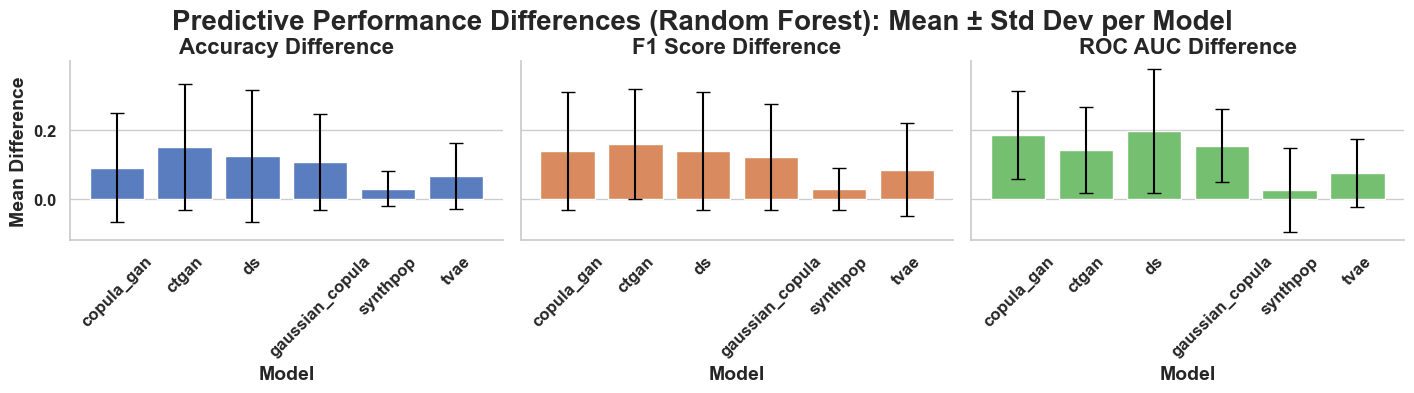

In [36]:
# Load the CSV file
df = pd.read_csv("../data/results/tables/rf.csv")  # Make sure the file path is correct

# Reshape the DataFrame for plotting
df_melted = df.melt(
    id_vars=["Dataset", "Model"],
    value_vars=["Accuracy Difference", "F1 Score Difference", "ROC AUC Difference"],
    var_name="Metric",
    value_name="Difference"
)

# Compute mean and std for each model-metric pair
summary = df_melted.groupby(["Model", "Metric"])["Difference"].agg(['mean', 'std']).reset_index()

# Set style
sns.set_theme(style="whitegrid")

# Create the barplot with subplots per metric
g = sns.catplot(
    data=summary,
    kind="bar",
    x="Model",
    y="mean",
    hue="Metric",
    col="Metric",
    errorbar=None,
    palette="muted",
    height=4,
    aspect=1.2,
    legend=False
)

# Add standard deviation error bars manually
for ax, metric in zip(g.axes[0], summary["Metric"].unique()):
    subset = summary[summary["Metric"] == metric]
    ax.errorbar(
        x=np.arange(len(subset)),
        y=subset["mean"],
        yerr=subset["std"],
        fmt='none',
        c='black',
        capsize=5
    )
    ax.set_title(metric, fontsize=16, fontweight='bold')
    ax.set_ylabel("Mean Difference", fontsize=14, fontweight='bold')
    ax.set_xlabel("Model", fontsize=14, fontweight='bold')

    for label in ax.get_xticklabels():
        label.set_fontsize(12)
        label.set_fontweight('bold')
        label.set_rotation(45)
    for label in ax.get_yticklabels():
        label.set_fontsize(12)
        label.set_fontweight('bold')

# Final adjustments
plt.tight_layout()
g.figure.subplots_adjust(top=0.85)
g.figure.suptitle("Predictive Performance Differences (Random Forest): Mean ± Std Dev per Model",
                   fontsize=20,
                   fontweight='bold')

# Save the plot
plt.savefig('../final_results/plots/utility/rf_barplot.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


**Visualize as heatmap**

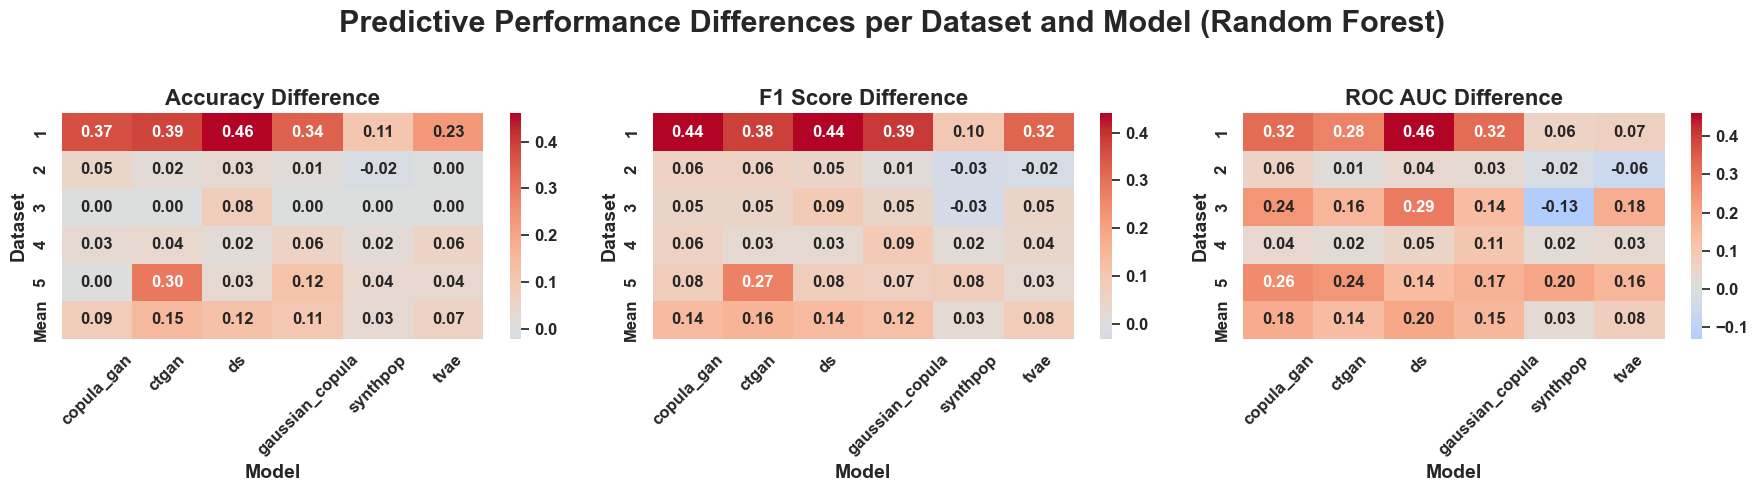

In [ ]:
# Load your data
df = pd.read_csv("../data/results/tables/rf.csv")  # Update path if needed

# Reshape the data to long format
df_melted = df.melt(
    id_vars=["Dataset", "Model"],
    value_vars=["Accuracy Difference", "F1 Score Difference", "ROC AUC Difference"],
    var_name="Metric",
    value_name="Difference"
)

# Generate heatmaps for each metric
metrics = df_melted["Metric"].unique()

# Create subplots for each metric
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    # Filter and pivot for heatmap
    data = df_melted[df_melted["Metric"] == metric]
    pivot = data.pivot(index="Dataset", columns="Model", values="Difference")

    # Compute the mean row and add it
    pivot.loc["Mean"] = pivot.mean()

    # Draw heatmap
    heatmap = sns.heatmap(pivot,
                annot=True,
                fmt=".2f", 
                cmap="coolwarm", 
                center=0, ax=ax, 
                annot_kws={"fontweight": "bold"})
    
    # Make colorbar bold
    cbar = heatmap.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)
    for label in cbar.ax.get_yticklabels():
        label.set_fontweight('bold')

    # Set titles and labels
    ax.set_title(metric, fontsize=16, fontweight='bold')
    ax.set_xlabel("Model", fontsize=14, fontweight='bold')
    ax.set_ylabel("Dataset", fontsize=14, fontweight='bold')

    # Set font sizes and styles for tick labels
    for label in ax.get_xticklabels():
        label.set_fontsize(12)
        label.set_fontweight('bold')
        label.set_rotation(45)
    for label in ax.get_yticklabels():
        label.set_fontsize(12)
        label.set_fontweight('bold')


# Adjust layout
plt.suptitle("Predictive Performance Differences per Dataset and Model (Random Forest)",
              fontsize=22,
              fontweight='bold',)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the plot
plt.savefig('../final_results/plots/utility/rf_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

### **Logistic Regression**

**Save in table**

In [ ]:
# Load LR results
lr_test = pd.read_csv('../data/results/tables/lr.csv')

# Calculate average values for each model
average_values = lr_test.groupby('Model')[['Accuracy Difference', 'F1 Score Difference', 'ROC AUC Difference']].mean().reset_index()

final_data = []

for model in lr_test['Model'].unique():
    
    model_data = lr_test[lr_test['Model'] == model]
    
    for idx, row in model_data.iterrows():
        if idx == model_data.index[2]:  # Only add model name once
            final_data.append([row['Model'], row['Dataset'], row['Accuracy Difference'], row['F1 Score Difference'], row['ROC AUC Difference']])
        else:
            final_data.append(['', row['Dataset'], row['Accuracy Difference'], row['F1 Score Difference'], row['ROC AUC Difference']])
    
    # Add average values
    avg_row = average_values[average_values['Model'] == model].iloc[0]
    final_data.append(['', 'Average', avg_row['Accuracy Difference'], avg_row['F1 Score Difference'], avg_row['ROC AUC Difference']])

# Create final dataframe
lr_df = pd.DataFrame(final_data, columns=['Model', 'Dataset', 'Accuracy Diff', 'F1 Score Diff', 'ROC AUC Diff']).round(2)
lr_df.to_csv('../final_results/combined_tables/lr.csv', index=False)

# Print as latex table
print(lr_df.to_latex(
    index=False,                 # Print row names
    float_format="%.2f",        # Set precision
    escape=True,                # Escape special characters
    bold_rows=True,             # Bold row names
    column_format="ccccc",     # Align columns
    header=True,                # Print column names
    label="tab:lr",        # Set label
    caption="Logistic Regression", # Set caption       
))
lr_df

\begin{table}
\caption{Logistic Regression}
\label{tab:lr}
\begin{tabular}{ccccc}
\toprule
Model & Dataset & Accuracy Diff & F1 Score Diff & ROC AUC Diff \\
\midrule
 & 1 & 0.08 & 0.09 & 0.03 \\
 & 2 & 0.04 & 0.04 & 0.01 \\
synthpop & 3 & 0.04 & 0.01 & 0.01 \\
 & 4 & 0.00 & 0.00 & -0.01 \\
 & 5 & 0.14 & 0.14 & 0.16 \\
 & Average & 0.06 & 0.06 & 0.04 \\
 & 1 & 0.38 & 0.38 & 0.46 \\
 & 2 & 0.07 & 0.21 & 0.11 \\
ds & 3 & 0.09 & 0.09 & 0.16 \\
 & 4 & 0.01 & 0.02 & 0.05 \\
 & 5 & 0.31 & 0.26 & 0.13 \\
 & Average & 0.17 & 0.19 & 0.18 \\
 & 1 & 0.12 & 0.21 & 0.16 \\
 & 2 & 0.00 & 0.01 & -0.01 \\
tvae & 4 & 0.04 & 0.00 & 0.00 \\
 & 5 & 0.25 & 0.24 & 0.12 \\
 & Average & 0.10 & 0.12 & 0.07 \\
 & 1 & 0.26 & 0.32 & 0.27 \\
 & 2 & 0.05 & 0.07 & 0.05 \\
gaussian\_copula & 3 & -0.17 & -0.15 & 0.03 \\
 & 4 & 0.03 & 0.12 & 0.05 \\
 & 5 & 0.27 & 0.25 & 0.15 \\
 & Average & 0.09 & 0.12 & 0.11 \\
 & 1 & 0.23 & 0.29 & 0.31 \\
 & 2 & 0.16 & 0.20 & 0.18 \\
copula\_gan & 3 & -0.04 & -0.02 & 0.11 \\
 & 4 & 0.

,Model,Dataset,Accuracy Diff,F1 Score Diff,ROC AUC Diff
0,,1,0.08,0.09,0.03
1,,2,0.04,0.04,0.01
2,synthpop,3,0.04,0.01,0.01
3,,4,0.00,0.00,-0.01
4,,5,0.14,0.14,0.16
5,,Average,0.06,0.06,0.04
6,,1,0.38,0.38,0.46
7,,2,0.07,0.21,0.11
8,ds,3,0.09,0.09,0.16
9,,4,0.01,0.02,0.05


**Visualize as barplot**

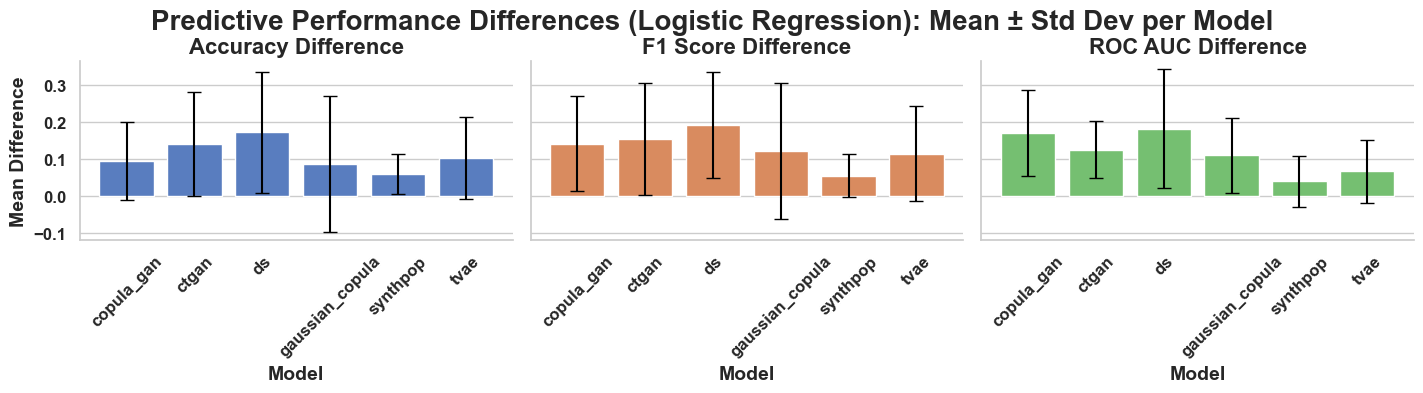

In [ ]:
# Load the CSV file
df = pd.read_csv("../data/results/tables/lr.csv")  # Make sure the file path is correct

# Reshape the DataFrame for plotting
df_melted = df.melt(
    id_vars=["Dataset", "Model"],
    value_vars=["Accuracy Difference", "F1 Score Difference", "ROC AUC Difference"],
    var_name="Metric",
    value_name="Difference"
)

# Compute mean and std for each model-metric pair
summary = df_melted.groupby(["Model", "Metric"])["Difference"].agg(['mean', 'std']).reset_index()

# Set style
sns.set_theme(style="whitegrid")

# Create the barplot with subplots per metric
g = sns.catplot(
    data=summary,
    kind="bar",
    x="Model",
    y="mean",
    hue="Metric",
    col="Metric",
    errorbar=None,
    palette="muted",
    height=4,
    aspect=1.2,
    legend=False
)

# Add standard deviation error bars manually
for ax, metric in zip(g.axes[0], summary["Metric"].unique()):
    subset = summary[summary["Metric"] == metric]
    ax.errorbar(
        x=np.arange(len(subset)),
        y=subset["mean"],
        yerr=subset["std"],
        fmt='none',
        c='black',
        capsize=5
    )
    ax.set_title(metric, fontsize=16, fontweight='bold')
    ax.set_ylabel("Mean Difference", fontsize=14, fontweight='bold')
    ax.set_xlabel("Model", fontsize=14, fontweight='bold')
    for label in ax.get_xticklabels():
        label.set_fontsize(12)
        label.set_fontweight('bold')
        label.set_rotation(45)
    for label in ax.get_yticklabels():
        label.set_fontsize(12)
        label.set_fontweight('bold')

# Final adjustments
plt.tight_layout()
g.figure.subplots_adjust(top=0.85)
g.figure.suptitle("Predictive Performance Differences (Logistic Regression): Mean ± Std Dev per Model",
                   fontsize=20,
                   fontweight='bold')

# Save the plot
plt.savefig('../final_results/plots/utility/lr_barplot.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

**Visualize as heatmap**

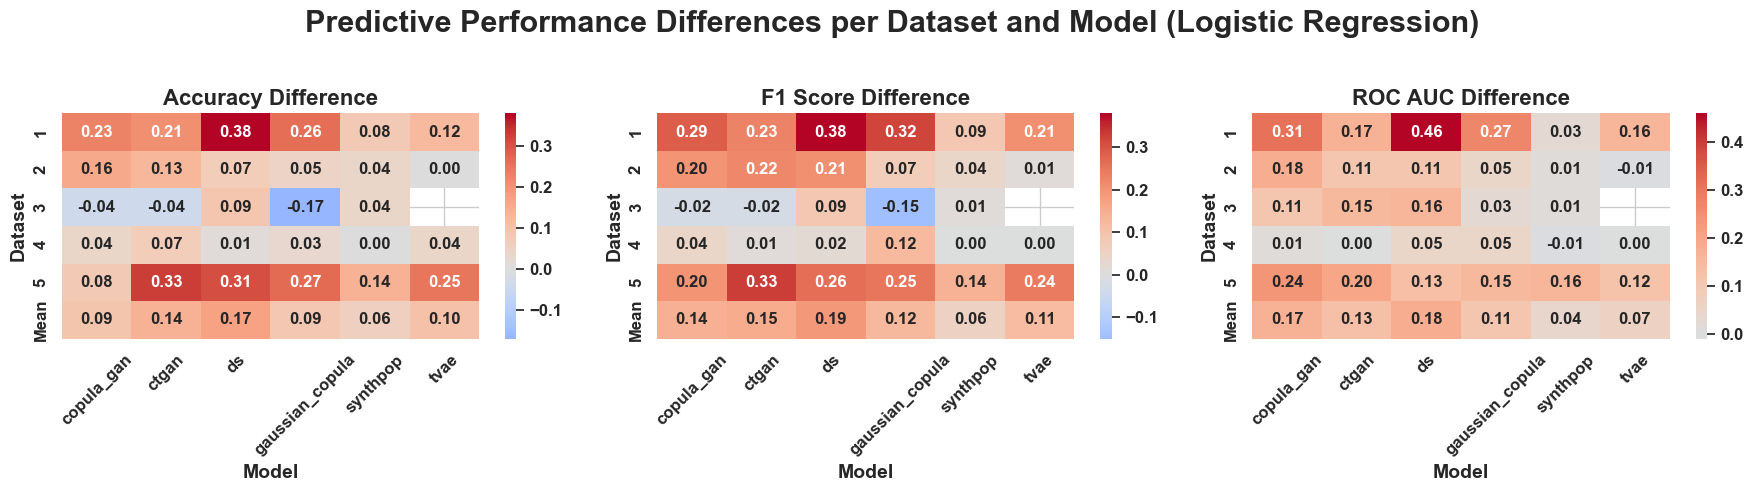

In [ ]:
# Load your data
df = pd.read_csv("../data/results/tables/lr.csv")  # Update path if needed

# Reshape the data to long format
df_melted = df.melt(
    id_vars=["Dataset", "Model"],
    value_vars=["Accuracy Difference", "F1 Score Difference", "ROC AUC Difference"],
    var_name="Metric",
    value_name="Difference"
)

# Generate heatmaps for each metric
metrics = df_melted["Metric"].unique()

# Create subplots for each metric
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    # Filter and pivot for heatmap
    data = df_melted[df_melted["Metric"] == metric]
    pivot = data.pivot(index="Dataset", columns="Model", values="Difference")

    # Compute the mean row and add it
    pivot.loc["Mean"] = pivot.mean()

    # Draw heatmap
    heatmap = sns.heatmap(pivot, 
                annot=True, 
                fmt=".2f", 
                cmap="coolwarm", 
                center=0, 
                ax=ax,
                annot_kws={"fontweight": "bold"})
    
    # Make colorbar bold
    cbar = heatmap.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)
    for label in cbar.ax.get_yticklabels():
        label.set_fontweight('bold')
    
    # Set titles and labels
    ax.set_title(metric, fontsize=16, fontweight='bold')
    ax.set_xlabel("Model", fontsize=14, fontweight='bold')
    ax.set_ylabel("Dataset", fontsize=14, fontweight='bold')

    # Set font sizes and styles for tick labels
    for label in ax.get_xticklabels():
        label.set_fontsize(12)
        label.set_fontweight('bold')
        label.set_rotation(45)
    for label in ax.get_yticklabels():
        label.set_fontsize(12)
        label.set_fontweight('bold')


# Adjust layout
plt.suptitle("Predictive Performance Differences per Dataset and Model (Logistic Regression)", 
             fontsize=22,
             fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the plot
plt.savefig('../final_results/plots/utility/lr_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

### **Multilayer Perceptron**

**Save in table**

In [ ]:
# Load MLP results
mlp_test = pd.read_csv('../data/results/tables/mlp.csv')

# Calculate average values for each model
average_values = mlp_test.groupby('Model')[['Accuracy Difference', 'F1 Score Difference', 'ROC AUC Difference']].mean().reset_index()

final_data = []


for model in mlp_test['Model'].unique():
    
    model_data = mlp_test[mlp_test['Model'] == model]
    
    for idx, row in model_data.iterrows():
        if idx == model_data.index[2]:  # Only add model name once
            final_data.append([row['Model'], row['Dataset'], row['Accuracy Difference'], row['F1 Score Difference'], row['ROC AUC Difference']])
        else:
            final_data.append(['', row['Dataset'], row['Accuracy Difference'], row['F1 Score Difference'], row['ROC AUC Difference']])
    
    # Add average values
    avg_row = average_values[average_values['Model'] == model].iloc[0]
    final_data.append(['', 'Average', avg_row['Accuracy Difference'], avg_row['F1 Score Difference'], avg_row['ROC AUC Difference']])

# Create final dataframe
mlp_df = pd.DataFrame(final_data, columns=['Model', 'Dataset', 'Accuracy Diff', 'F1 Score Diff', 'ROC AUC Diff']).round(2)
mlp_df.to_csv('../final_results/combined_tables/mlp.csv', index=False)

# Print as latex table
print(mlp_df.to_latex(
    index=False,                 # Print row names
    float_format="%.2f",        # Set precision
    escape=True,                # Escape special characters
    bold_rows=True,             # Bold row names
    column_format="ccccc",     # Align columns
    header=True,                # Print column names
    label="tab:mlp",        # Set label
    caption="Multilayer Perceptron", # Set caption       
))
mlp_df

\begin{table}
\caption{Multilayer Perceptron}
\label{tab:mlp}
\begin{tabular}{ccccc}
\toprule
Model & Dataset & Accuracy Diff & F1 Score Diff & ROC AUC Diff \\
\midrule
 & 1 & 0.09 & 0.09 & 0.04 \\
 & 2 & 0.01 & 0.00 & 0.02 \\
synthpop & 3 & 0.00 & 0.00 & -0.03 \\
 & 4 & 0.07 & 0.06 & 0.01 \\
 & 5 & 0.15 & 0.15 & 0.15 \\
 & Average & 0.06 & 0.06 & 0.04 \\
 & 1 & 0.46 & 0.43 & 0.44 \\
 & 2 & 0.04 & 0.15 & 0.11 \\
ds & 3 & 0.21 & 0.12 & -0.08 \\
 & 4 & -0.08 & -0.07 & 0.00 \\
 & 5 & 0.14 & 0.14 & 0.14 \\
 & Average & 0.15 & 0.15 & 0.12 \\
 & 1 & 0.16 & 0.23 & 0.15 \\
 & 2 & -0.01 & -0.01 & 0.00 \\
tvae & 3 & 0.00 & 0.00 & 0.00 \\
 & 4 & -0.08 & -0.08 & 0.00 \\
 & 5 & 0.18 & 0.17 & 0.09 \\
 & Average & 0.05 & 0.06 & 0.05 \\
 & 1 & 0.23 & 0.24 & 0.20 \\
 & 2 & 0.03 & 0.03 & 0.06 \\
gaussian\_copula & 3 & 0.00 & 0.00 & 0.01 \\
 & 4 & 0.07 & 0.06 & 0.01 \\
 & 5 & 0.26 & 0.23 & 0.20 \\
 & Average & 0.12 & 0.11 & 0.10 \\
 & 1 & 0.16 & 0.17 & 0.22 \\
 & 2 & 0.14 & 0.18 & 0.17 \\
copula\_gan & 3

,Model,Dataset,Accuracy Diff,F1 Score Diff,ROC AUC Diff
0,,1,0.09,0.09,0.04
1,,2,0.01,0.00,0.02
2,synthpop,3,0.00,0.00,-0.03
3,,4,0.07,0.06,0.01
4,,5,0.15,0.15,0.15
5,,Average,0.06,0.06,0.04
6,,1,0.46,0.43,0.44
7,,2,0.04,0.15,0.11
8,ds,3,0.21,0.12,-0.08
9,,4,-0.08,-0.07,0.00


**Visualize as barplot**

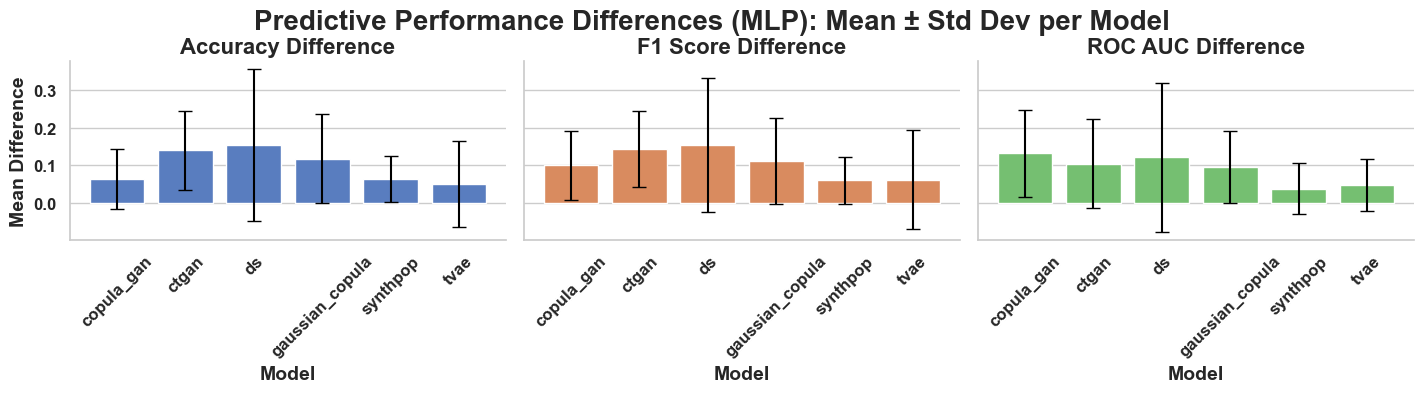

In [ ]:
# Load the CSV file
df = pd.read_csv("../data/results/tables/mlp.csv")  # Make sure the file path is correct

# Reshape the DataFrame for plotting
df_melted = df.melt(
    id_vars=["Dataset", "Model"],
    value_vars=["Accuracy Difference", "F1 Score Difference", "ROC AUC Difference"],
    var_name="Metric",
    value_name="Difference"
)

# Compute mean and std for each model-metric pair
summary = df_melted.groupby(["Model", "Metric"])["Difference"].agg(['mean', 'std']).reset_index()

# Set style
sns.set_theme(style="whitegrid")

# Create the barplot with subplots per metric
g = sns.catplot(
    data=summary,
    kind="bar",
    x="Model",
    y="mean",
    hue="Metric",
    col="Metric",
    errorbar=None,
    palette="muted",
    height=4,
    aspect=1.2,
    legend=False
)

# Add standard deviation error bars manually
for ax, metric in zip(g.axes[0], summary["Metric"].unique()):
    subset = summary[summary["Metric"] == metric]
    ax.errorbar(
        x=np.arange(len(subset)),
        y=subset["mean"],
        yerr=subset["std"],
        fmt='none',
        c='black',
        capsize=5
    )
    ax.set_title(metric, fontsize=16, fontweight='bold')
    ax.set_ylabel("Mean Difference", fontsize=14, fontweight='bold')
    ax.set_xlabel("Model", fontsize=14, fontweight='bold')
    for label in ax.get_xticklabels():
        label.set_fontsize(12)
        label.set_fontweight('bold')
        label.set_rotation(45)
    for label in ax.get_yticklabels():
        label.set_fontsize(12)
        label.set_fontweight('bold')

# Final adjustments
plt.tight_layout()
g.figure.subplots_adjust(top=0.85)
g.figure.suptitle("Predictive Performance Differences (MLP): Mean ± Std Dev per Model",
                   fontsize=20,
                   fontweight='bold')

# Save the plot
plt.savefig('../final_results/plots/utility/mlp_barplot.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

**Visualize as heatmap**

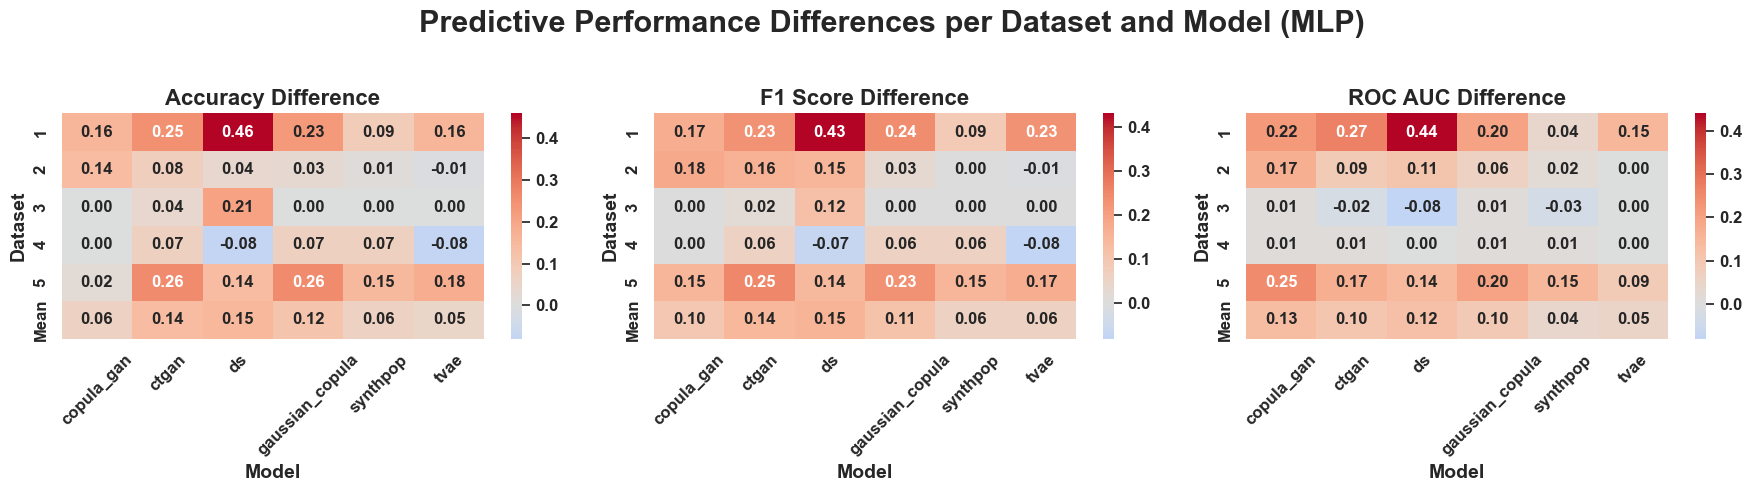

In [ ]:
# Load your data
df = pd.read_csv("../data/results/tables/mlp.csv")  # Update path if needed

# Reshape the data to long format
df_melted = df.melt(
    id_vars=["Dataset", "Model"],
    value_vars=["Accuracy Difference", "F1 Score Difference", "ROC AUC Difference"],
    var_name="Metric",
    value_name="Difference"
)

# Generate heatmaps for each metric
metrics = df_melted["Metric"].unique()

# Create subplots for each metric
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    # Filter and pivot for heatmap
    data = df_melted[df_melted["Metric"] == metric]
    pivot = data.pivot(index="Dataset", columns="Model", values="Difference")

    # Compute the mean row and add it
    pivot.loc["Mean"] = pivot.mean()

    # Draw heatmap
    heatmap = sns.heatmap(pivot, 
                annot=True, 
                fmt=".2f", 
                cmap="coolwarm", 
                center=0, 
                ax=ax,
                annot_kws={"fontweight": "bold"})
    
    # Make colorbar bold
    cbar = heatmap.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)
    for label in cbar.ax.get_yticklabels():
        label.set_fontweight('bold')

    # Set titles and labels
    ax.set_title(metric, fontsize=16, fontweight='bold')
    ax.set_xlabel("Model", fontsize=14, fontweight='bold')
    ax.set_ylabel("Dataset", fontsize=14, fontweight='bold')

    # Set font size and weight for tick labels
    for label in ax.get_xticklabels():
        label.set_fontsize(12)
        label.set_fontweight('bold')
        label.set_rotation(45)
    for label in ax.get_yticklabels():
        label.set_fontsize(12)
        label.set_fontweight('bold')


# Adjust layout
plt.suptitle("Predictive Performance Differences per Dataset and Model (MLP)", 
             fontsize=22,
             fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the plot
plt.savefig('../final_results/plots/utility/mlp_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

**Compute the average of all utility averages**

In [ ]:
for df in [rf_df, lr_df, mlp_df]:
    df["Model"].replace("", None, inplace=True)
    df["Model"].ffill(inplace=True)

# Cut out the average rows
rf_avgs = rf_df[rf_df['Dataset'] == 'Average']
lr_avgs = lr_df[lr_df['Dataset'] == 'Average']
mlp_avgs = mlp_df[mlp_df['Dataset'] == 'Average']

# Combine the average rows into one dataframe
utility_avg = pd.concat([rf_avgs, lr_avgs, mlp_avgs])

# Calculate average values for each model
result = utility_avg.groupby("Model")[["Accuracy Diff", "F1 Score Diff", "ROC AUC Diff"]].mean().round(2)

# Print as latex table
print(result.to_latex(
    index=True,                 # Print row names
    float_format="%.2f",        # Set precision
    escape=True,                # Escape special characters
    column_format="lc",    # Align columns
    header=True,                # Print column names
    label="tab:utility_avg",        # Set label
    caption="Average Utility", # Set caption
    multicolumn=True,
    multirow=True
))

\begin{table}
\caption{Average Utility}
\label{tab:utility_avg}
\begin{tabular}{lc}
\toprule
 & Accuracy Diff & F1 Score Diff & ROC AUC Diff \\
Model &  &  &  \\
\midrule
copula\_gan & 0.08 & 0.13 & 0.16 \\
ctgan & 0.14 & 0.15 & 0.12 \\
ds & 0.15 & 0.16 & 0.17 \\
gaussian\_copula & 0.11 & 0.12 & 0.12 \\
synthpop & 0.05 & 0.05 & 0.04 \\
tvae & 0.07 & 0.09 & 0.07 \\
\bottomrule
\end{tabular}
\end{table}



/var/folders/3r/t5vbz_596wl1kpp2c5b396qc0000gn/T/ipykernel_1977/1606817948.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Model"].replace("", None, inplace=True)
/var/folders/3r/t5vbz_596wl1kpp2c5b396qc0000gn/T/ipykernel_1977/1606817948.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

**Save DCR and MIA plots in _final_results_**

In [ ]:
# Save plots also in Final_Results
import shutil
import os

# Define the source and destination directories
mia_plots_src = '../data/results/plots/mia/'
dcr_plots_src = '../data/results/plots/dcr/'
mia_plots_dest = '../final_results/plots/mia/'
dcr_plots_dest = '../final_results/plots/dcr/'

# Remove the destination directory if it exists
if os.path.exists(mia_plots_dest):
    shutil.rmtree(mia_plots_dest)
# Remove the destination directory if it exists
if os.path.exists(dcr_plots_dest):
    shutil.rmtree(dcr_plots_dest)

# Copy all files from source to destination
shutil.copytree(mia_plots_src, mia_plots_dest)
shutil.copytree(dcr_plots_src, dcr_plots_dest)


'../final_results/plots'